In [1]:
#PACKAGES
import numpy as np
import pylab
import math
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pyunicorn.timeseries import RecurrenceNetwork
from pyunicorn.timeseries import RecurrencePlot
from pyunicorn.core import Network
rcParams.update({'font.size': 15})
plt.rcParams['figure.figsize'] = [8, 5]
import sys,os, shutil
from packaging import version
import importlib
import pandas as pd
import subprocess
import glob
from tqdm import tqdm
import warnings
!chmod +x ./mutual
!chmod +x ./false_nearest

In [2]:
#FUNCTIONS
def open_file(rootfilename, dimension,thr):
    surro_DET = []
    surro_LAM = []
    surro_ENTR = []
    for i in range(1,10):
        file = rootfilename + "_00" + str(i) 
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension, tau=t_min, metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
    for j in range (10, 100):
        file = rootfilename + "_0" + str(j)
        data = np.loadtxt(file) 
        surro_rp_data = RecurrencePlot(data, dim =dimension , tau=t_min,  metric="euclidean", threshold=thr, normalize=True, silence_level = 3)
        RRsur = surro_rp_data.recurrence_rate()
        DETsur = surro_rp_data.determinism(l_min=2)
        LAMsur = surro_rp_data.laminarity(v_min=2)
        ENTRsur = surro_rp_data.diag_entropy(l_min=2, resampled_dist=None)
        surro_DET.append(DETsur)
        surro_LAM.append(LAMsur)
        surro_ENTR.append(ENTRsur)
    return surro_DET, surro_LAM, surro_ENTR

def lcurve(p):
    lc = np.loadtxt("{}".format(p), delimiter=" ", usecols=0)
    np.savetxt("surro_index/qp", lc)
    return lc


def RP_RN(l, dimension, thr):
    qpo_rp = RecurrencePlot(l, dim=dimension , tau=t_min, metric = "euclidean", threshold=thr, normalize=True, silence_level = 3)
    RRqpo = qpo_rp.recurrence_rate()
    DETqpo = qpo_rp.determinism(l_min=2)
    LAMqpo = qpo_rp.laminarity(v_min=2)
    ENTRqpo = qpo_rp.diag_entropy(l_min=2, resampled_dist=None)
    matrix = qpo_rp.recurrence_matrix()
    return DETqpo, RRqpo, LAMqpo, ENTRqpo, matrix



In [3]:
col1, col2 = np.loadtxt("psei_monthly.csv", delimiter=",", usecols=(1, 2), skiprows=1, dtype=str, unpack=True )
patched = np.char.add(col1, col2)
data = patched.astype(float)
np.savetxt("stocks", data)

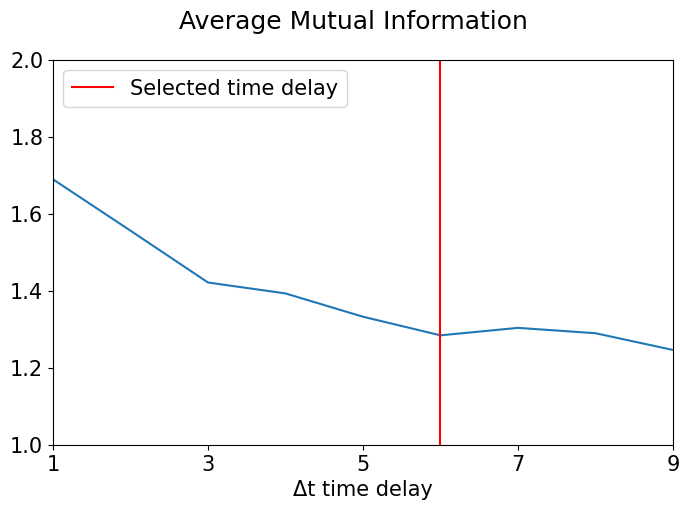

In [4]:
os.system("./mutual stocks -D9  -o files/mutual_stocks -V0")
m_site1 = np.loadtxt("files/mutual_stocks", delimiter =' ', usecols =(1) , skiprows=0)
fig2, axs = plt.subplots(1)
fig2.suptitle("Average Mutual Information")
axs.plot(m_site1)
plt.axvline(x = 6, color = 'red', label = 'Selected time delay')
plt.xticks(range(1,21,2))
axs.set_xlim([1, 9])
axs.set_ylim([1, 2])
plt.xlabel("Δt time delay")
plt.legend()
plt.show()
fig2.savefig('test_output/AMI.pdf', format="pdf", dpi=300)
plt.close()
t_min=6

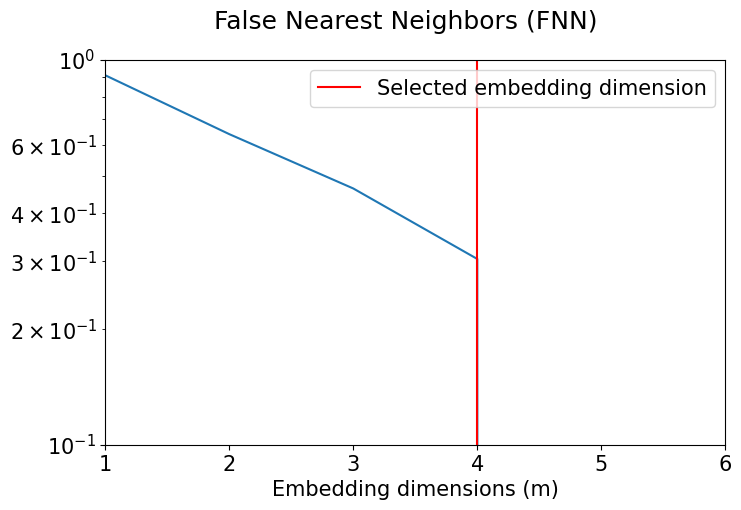

In [5]:
os.system("./false_nearest stocks -d6 -o files/stocks.fnn -V0")
m1 = np.loadtxt("files/stocks.fnn", usecols=1)
d1 = np.loadtxt("files/stocks.fnn", usecols=0)
fig2, ax = plt.subplots(1)
fig2.suptitle("False Nearest Neighbors (FNN)")
ax.plot(d1, m1)
ax.set_yscale("log")
plt.xticks(range(1,20,1))
plt.xlabel("Embedding dimensions (m)")
plt.axvline(x = 4, color = 'red', label = 'Selected embedding dimension')
plt.legend()
ax.set_xlim([1, 6])
ax.set_ylim([1e-1, 1])
fig2.savefig('test_output/FNN.pdf', format="pdf", dpi=300)
plt.show()
plt.close()

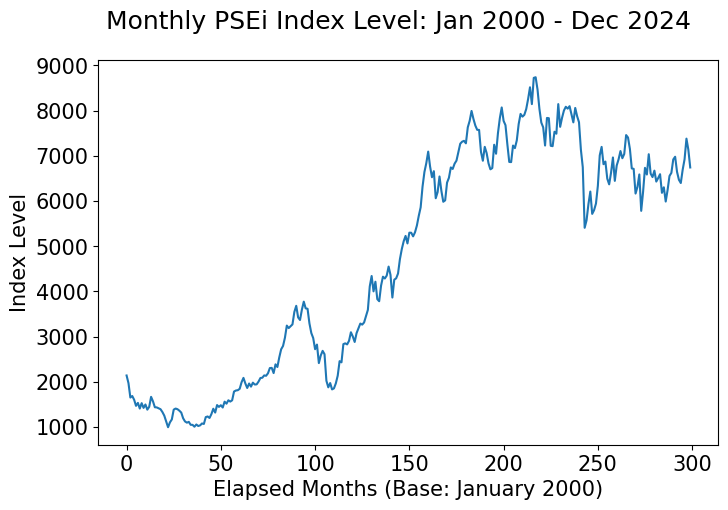

In [6]:
f1, ax1 = plt.subplots(1)
f1.suptitle("Monthly PSEi Index Level: Jan 2000 - Dec 2024")
ax1.plot(data)
plt.xlabel("Elapsed Months (Base: January 2000)")
plt.ylabel("Index Level")
f1.savefig('test_output/closing_price.pdf', format="pdf", dpi=300)

# WIAAFT surrogate test

In [7]:
def sur_test(l, m, thr):
    return open_file("surro_index/WIAAFT/qp_surr", m, thr)
    

WIAAFT surrogate datasets generated


  0%|                                                     | 0/5 [00:00<?, ?it/s]

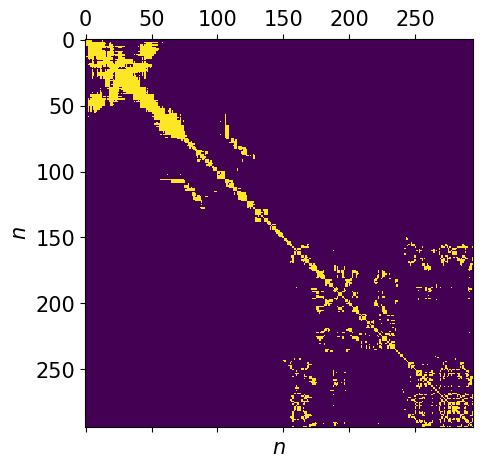

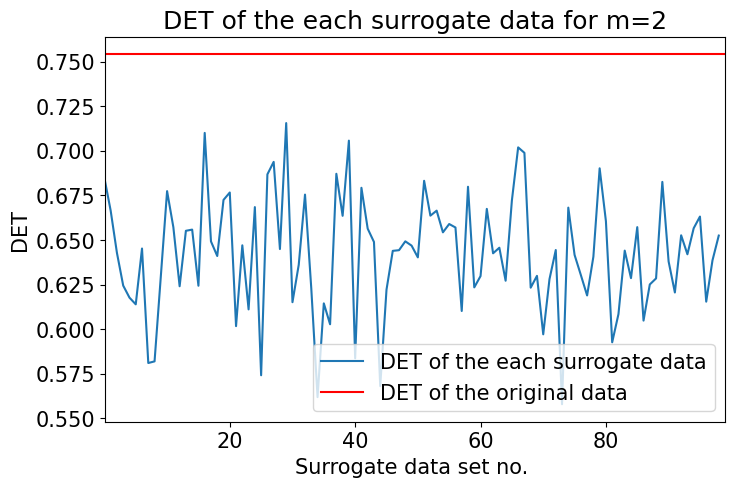

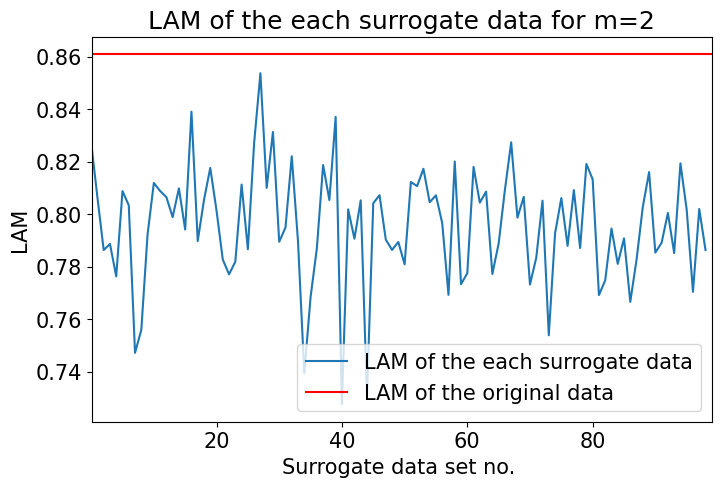

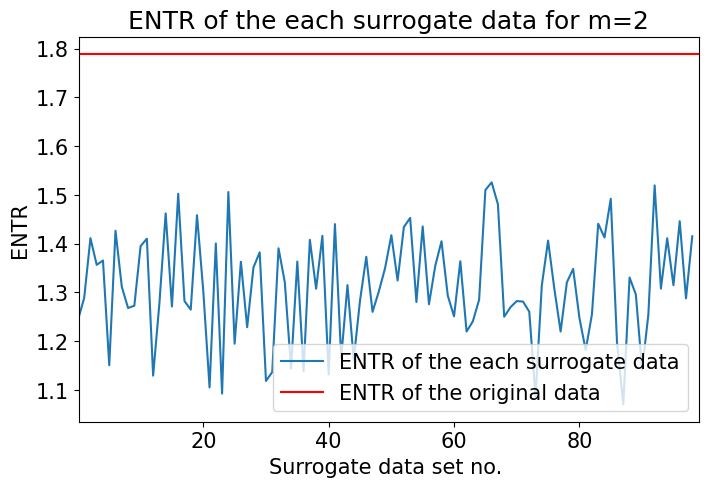

 20%|█████████                                    | 1/5 [00:02<00:08,  2.03s/it]

RQA  stocks Embedding dimensions:2 
 DET of original:0.7542204568005109 
 Recurrence rate: 0.05000231385071035 
Threshold:0.1599999999999987 
 Laminarity:0.8609440074019876 
Shannon Entropy:1.7887444109892805 
Rank-order p-value (det):0.01 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



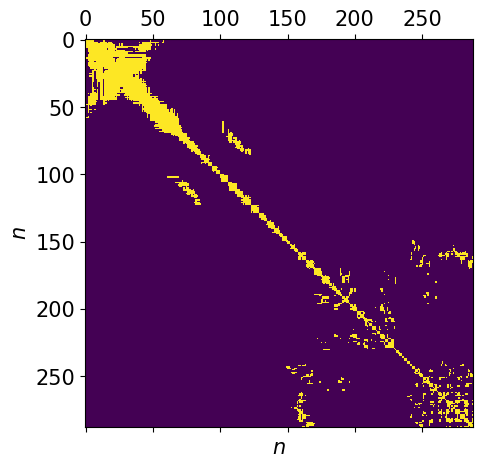

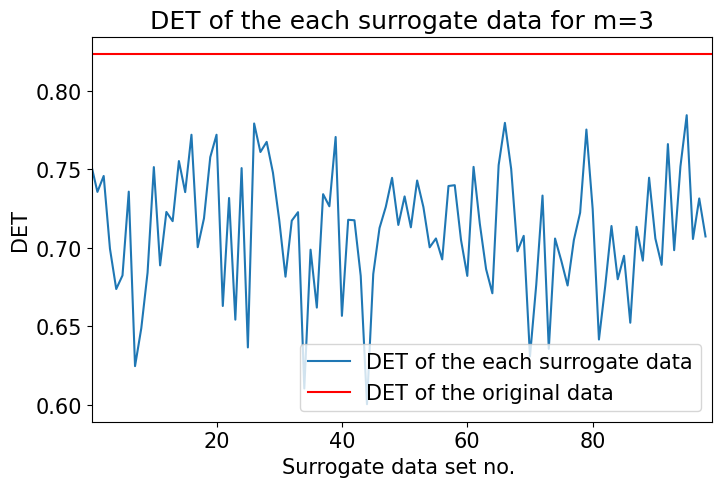

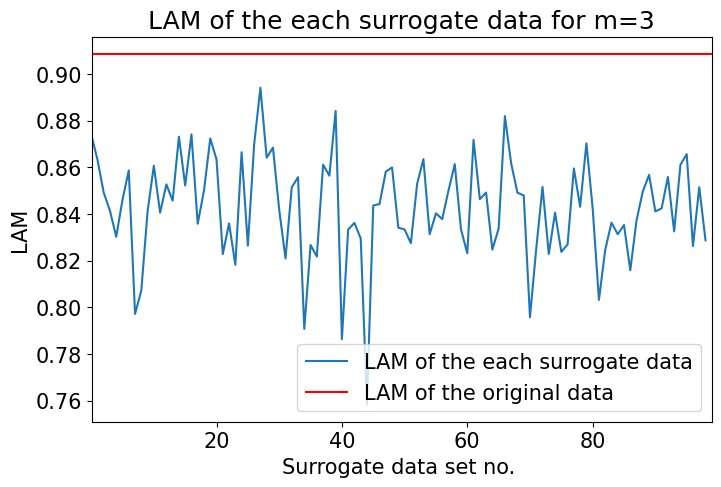

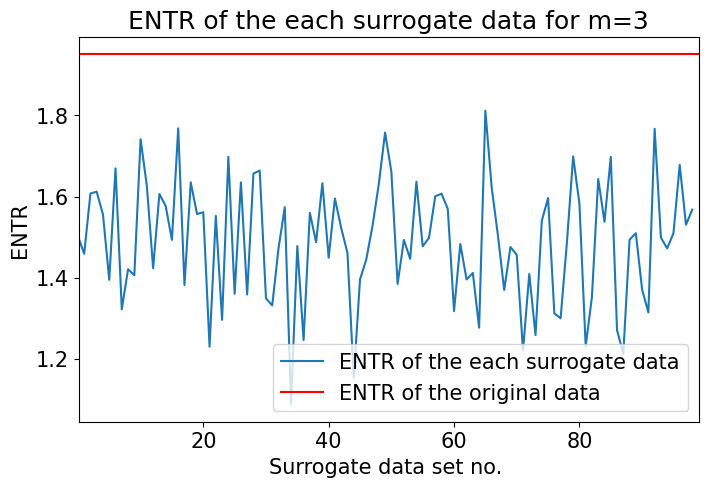

 40%|██████████████████                           | 2/5 [00:04<00:07,  2.40s/it]

RQA  stocks Embedding dimensions:3 
 DET of original:0.8234075608471688 
 Recurrence rate: 0.050033757716049385 
Threshold:0.23889999999999 
 Laminarity:0.9084337349375701 
Shannon Entropy:1.9508420715265373 
Rank-order p-value (det):0.01 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



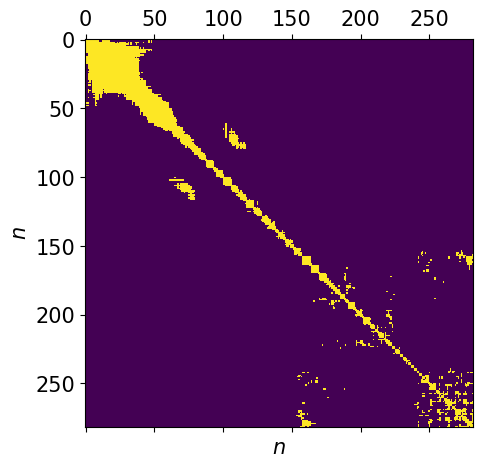

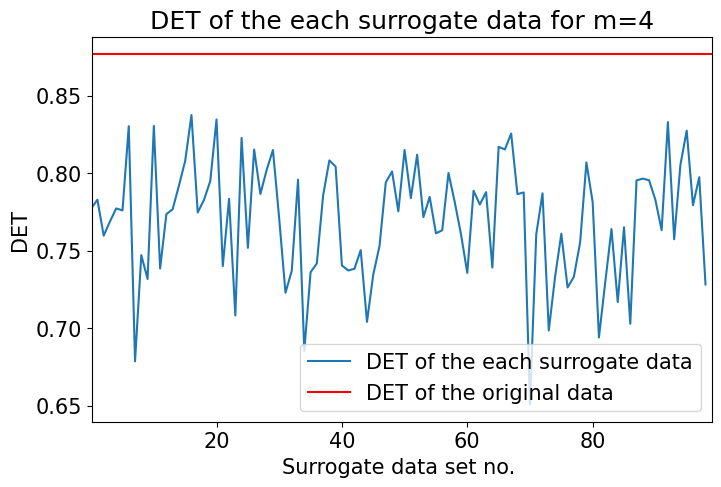

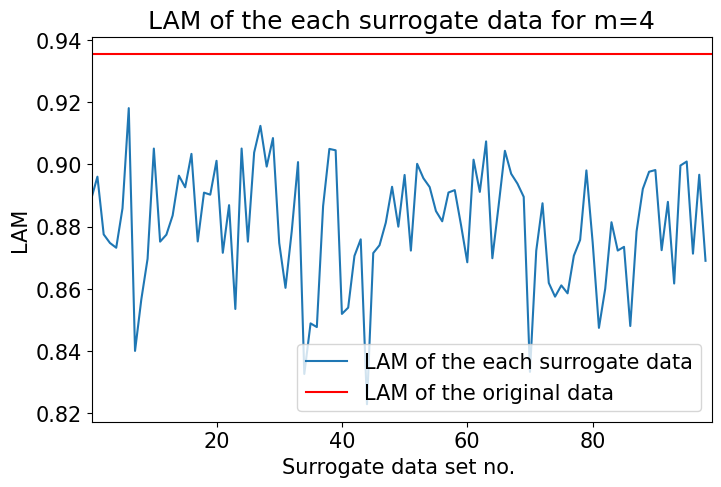

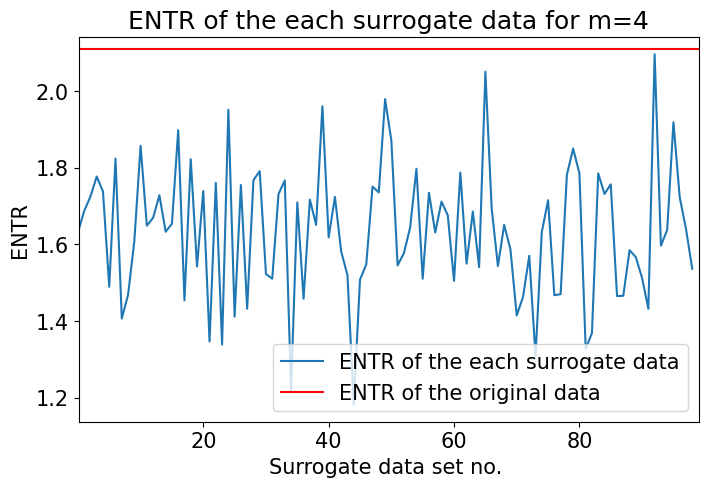

 60%|███████████████████████████                  | 3/5 [00:08<00:05,  2.87s/it]

RQA  stocks Embedding dimensions:4 
 DET of original:0.876690102755877 
 Recurrence rate: 0.050047784316684274 
Threshold:0.3259999999999804 
 Laminarity:0.9354271356760416 
Shannon Entropy:2.1089753584358295 
Rank-order p-value (det):0.01 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



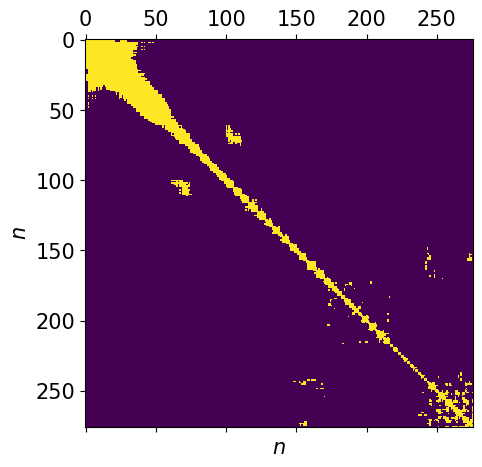

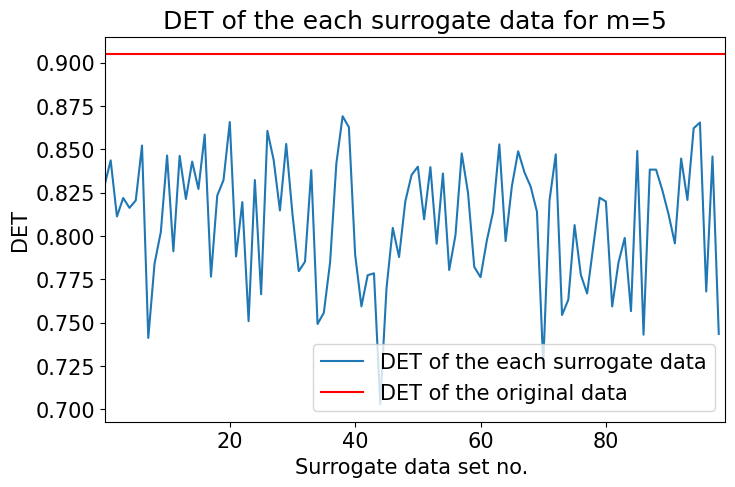

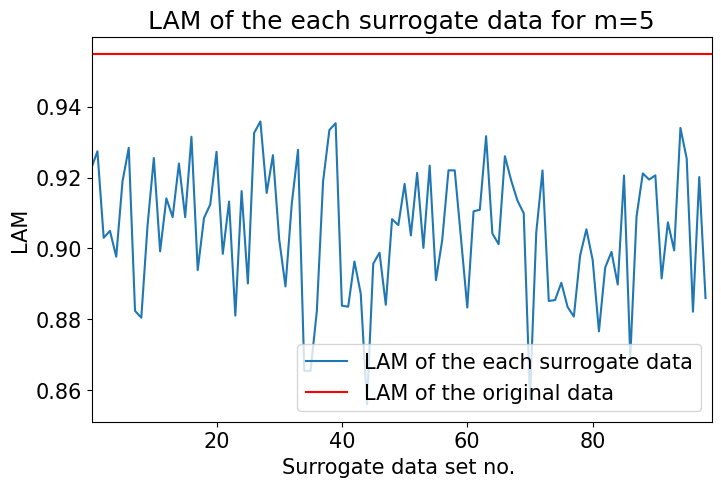

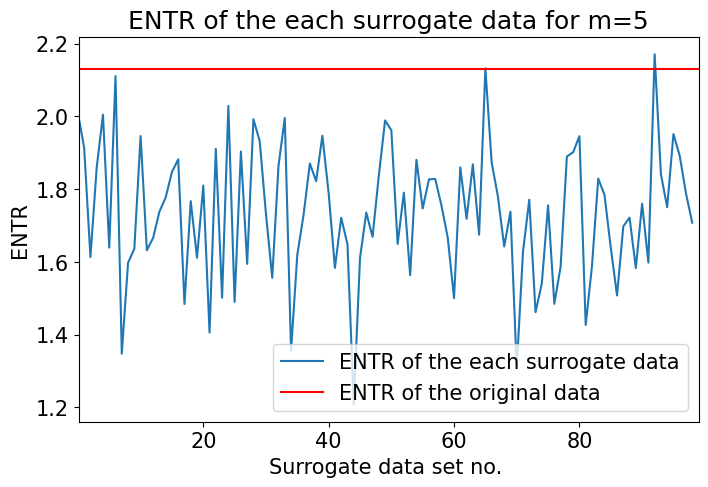

 80%|████████████████████████████████████         | 4/5 [00:12<00:03,  3.32s/it]

RQA  stocks Embedding dimensions:5 
 DET of original:0.9049235993183222 
 Recurrence rate: 0.050015752993068686 
Threshold:0.40469999999997175 
 Laminarity:0.9548556430421132 
Shannon Entropy:2.1310423583923637 
Rank-order p-value (det):0.01 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.03 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



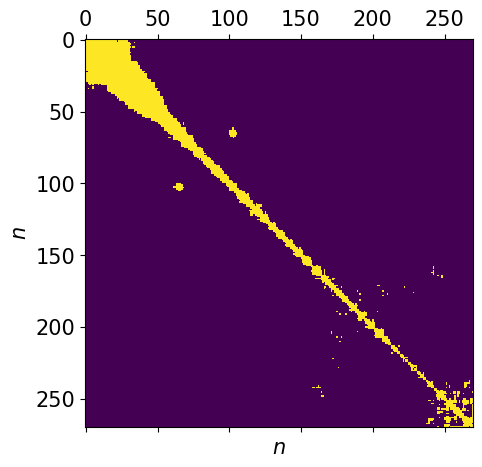

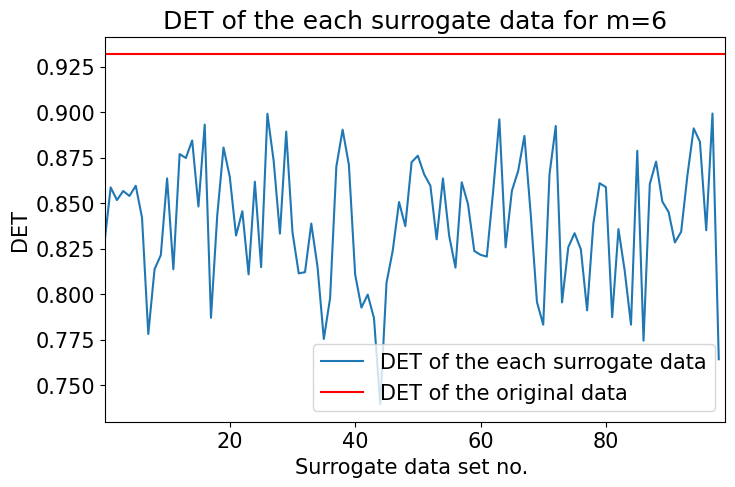

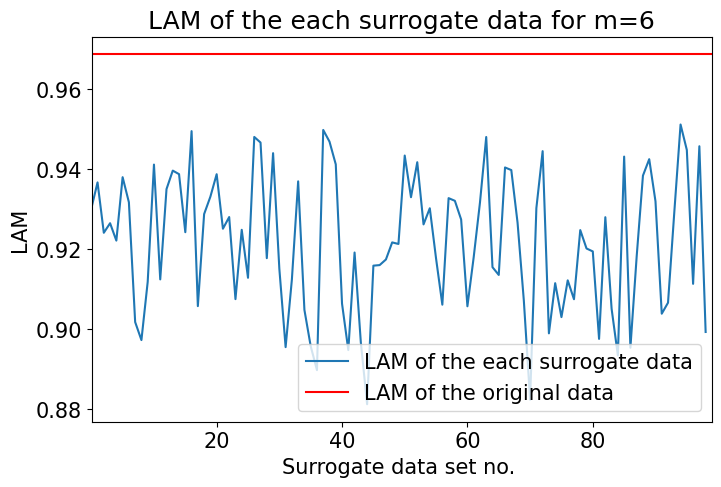

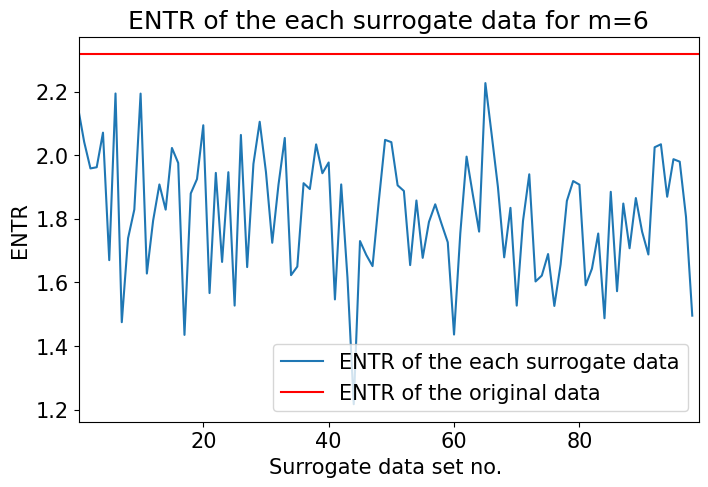

100%|█████████████████████████████████████████████| 5/5 [00:16<00:00,  3.35s/it]

RQA  stocks Embedding dimensions:6 
 DET of original:0.9318720379119317 
 Recurrence rate: 0.05001371742112483 
Threshold:0.48369999999996305 
 Laminarity:0.9687328579238379 
Shannon Entropy:2.318085964176623 
Rank-order p-value (det):0.01 
Rank-order p-value (lam):0.01 
Rank-order p-value (entr):0.01 
Reject null (det) hypothesis:True
 Reject null (lam) hypothesis:True
Reject null (entr) hypothesis:True
 
 



In [8]:
t_min=6
k="stocks"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
subprocess.run(["julia", "WIAAFT_surrogates.jl"], text=True, check=True)
with open("test_output/stocks_WIAAFT", "w") as f:
    for dim in tqdm(range(2, 7, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)
        pylab.matshow(matrix)
        pylab.xlabel("$n$")
        pylab.ylabel("$n$")
        pylab.savefig('test_output/WIAAFT/WIAAFT_RP_{}.pdf'.format(dim), format="pdf")
        det_ff, lam_ff, entr_ff = sur_test(s, dim, tt1)
        fig2, axs = plt.subplots(1)
        axs.plot(det_ff, label = 'DET of the each surrogate data')
        axs.set_title('DET of the each surrogate data for m={}'.format(dim))
        axs.axhline(y = det, color = 'r', linestyle = '-', label = 'DET of the original data' )
        axs.legend(loc='lower right')
        axs.set_xlabel("Surrogate data set no. ")
        axs.set_xlim(0.1, 99)
        axs.set_ylabel("DET")
        fig2.savefig('test_output/WIAAFT/surro_{}.pdf'.format(dim), format="pdf", dpi=300)
        plt.show()
        plt.close()
        fig, ax = plt.subplots(1)
        ax.plot(lam_ff, label = 'LAM of the each surrogate data')
        ax.set_title('LAM of the each surrogate data for m={}'.format(dim))
        ax.axhline(y = lam_orig, color = 'r', linestyle = '-', label = 'LAM of the original data' )
        ax.legend(loc='lower right')
        ax.set_xlabel("Surrogate data set no. ")
        ax.set_xlim(0.1, 99)
        ax.set_ylabel("LAM")
        fig.savefig('test_output/WIAAFT/surro_{}_LAM.pdf'.format(dim), format="pdf", dpi=300)
        plt.show()
        plt.close()
        fi, axx1 = plt.subplots(1)
        axx1.plot(entr_ff, label = 'ENTR of the each surrogate data')
        axx1.set_title('ENTR of the each surrogate data for m={}'.format(dim))
        axx1.axhline(y = entr_orig, color = 'r', linestyle = '-', label = 'ENTR of the original data' )
        axx1.legend(loc='lower right')
        axx1.set_xlabel("Surrogate data set no. ")
        axx1.set_xlim(0.1, 99)
        axx1.set_ylabel("ENTR")
        fi.savefig('test_output/WIAAFT/surro_{}_ENTR.pdf'.format(dim), format="pdf", dpi=300)
        plt.show()
        plt.close()
        r = np.sum(det_ff >= det)
        r1 = np.sum(lam_ff >= lam_orig)
        r2 = np.sum(entr_ff >= entr_orig)
        p_rank = (r + 1) / (99 + 1)
        p_rank_lam =(r1 + 1) / (99 + 1)
        p_rank_entr = (r2 + 1) / (99 + 1)
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(99, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

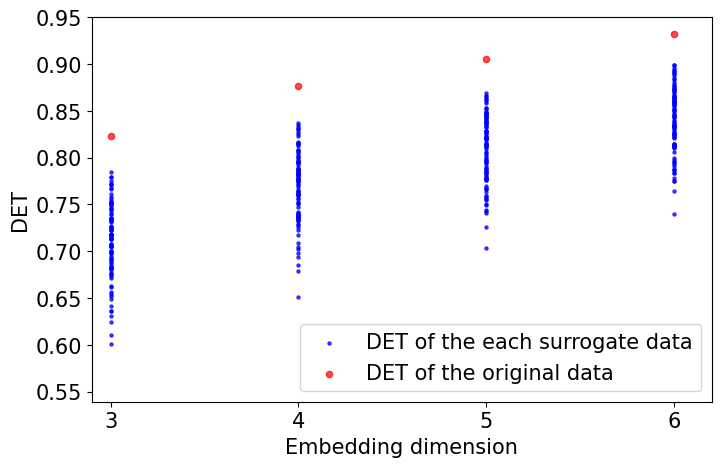

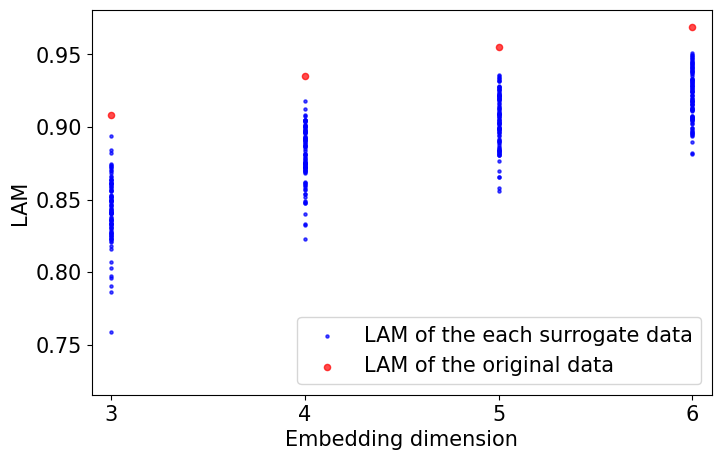

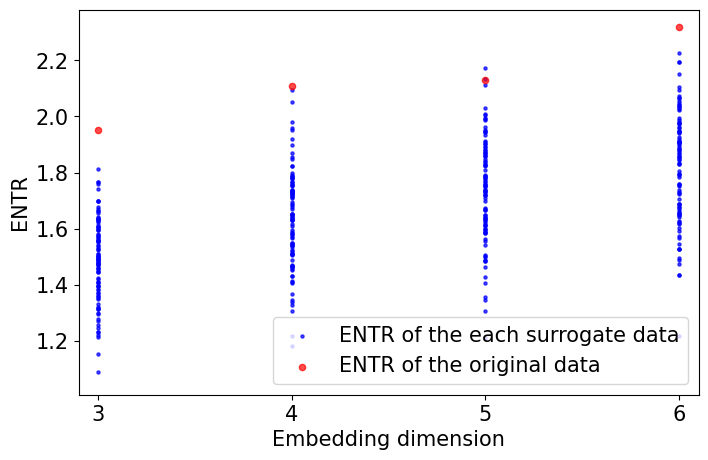

In [9]:
fig3, ax3 = plt.subplots(1)
ax3.scatter(np.concatenate(kkk), np.concatenate(det_surro_ff), color='blue', alpha=0.7, s=5, label = "DET of the each surrogate data")
ax3.scatter(embed, det_j, color='red', alpha=0.7, s=20, label='DET of the original data')
ax3.set_xlim(2.9, 6.2)
ax3.set_xticks(np.arange(3, 7, 1))
ax3.set_xlabel("Embedding dimension")
ax3.set_ylabel("DET")
ax3.legend(loc='lower right')
fig3.savefig('test_output/WIAAFT/WIAAFT_surro_m.pdf', format="pdf", dpi=300)
plt.show()
plt.close()
fig4, ax4 = plt.subplots(1)
ax4.scatter(np.concatenate(kkk), np.concatenate(lam_surro), color='blue', alpha=0.7, s=5, label = "LAM of the each surrogate data")
ax4.scatter(embed, lam_j, color='red', alpha=0.7, s=20, label='LAM of the original data')
ax4.set_xlim(2.9, 6.1)
ax4.set_xlabel("Embedding dimension")
ax4.set_ylabel("LAM")
ax4.legend(loc='lower right')
ax4.set_xticks(np.arange(3, 7, 1))
plt.show()
plt.close()
fig4.savefig('test_output/WIAAFT/WIAAFT_surro_lam_m.pdf', format="pdf", dpi=300)
fig5, ax5 = plt.subplots(1)
ax5.scatter(np.concatenate(kkk), np.concatenate(ent_surro), color='blue', alpha=0.7, s=5, label = "ENTR of the each surrogate data")
ax5.scatter(embed, ent_j, color='red', alpha=0.7, s=20, label='ENTR of the original data')    
ax5.set_xlim(2.9, 6.1)
ax5.set_xlabel("Embedding dimension")
ax5.set_ylabel("ENTR")
ax5.legend(loc='lower right')
ax5.set_xticks(np.arange(3, 7, 1))
fig5.savefig('test_output/WIAAFT/WIAAFT_surro_entr_m.pdf', format="pdf", dpi=300)
plt.show()
plt.close()

# PP surrogate test

In [10]:
def sur_test_PP(l, m, thr):
    return open_file("surro_index/PP/qp_surr", m, thr)

  0%|                                                     | 0/5 [00:00<?, ?it/s]

Mean Nearest Neighbor Distance: 0.04290669332870649
Pseudo-periodic surrogates generated successfullly


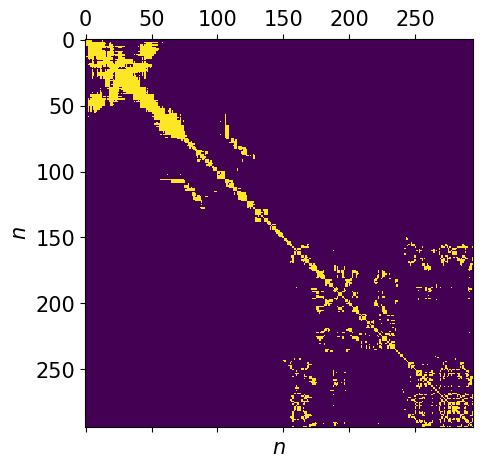

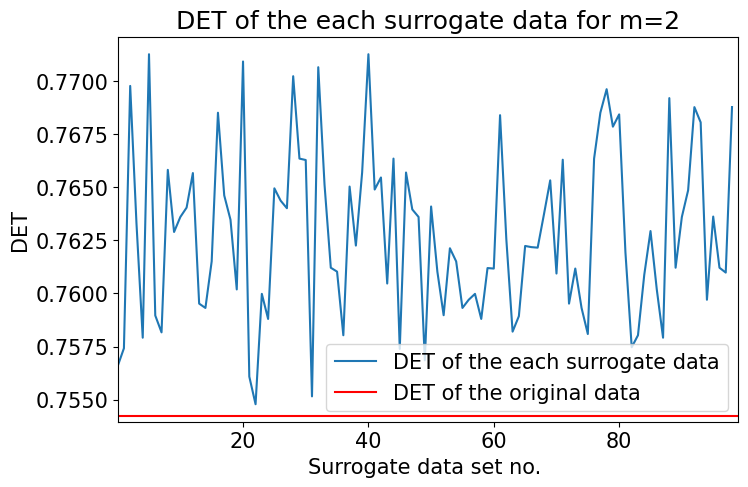

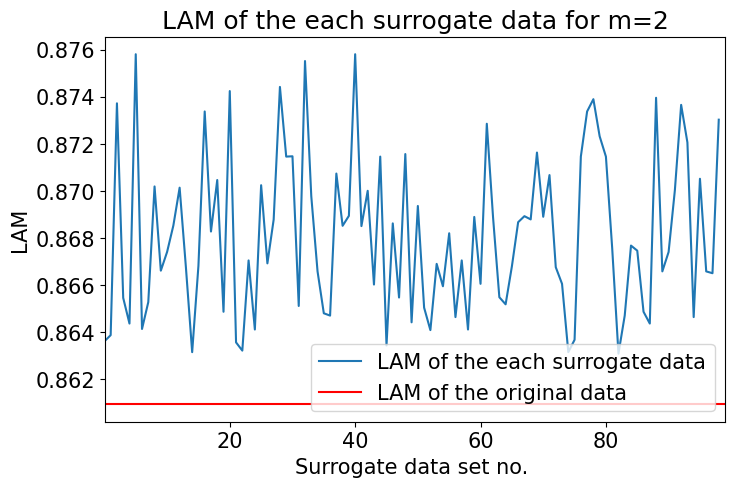

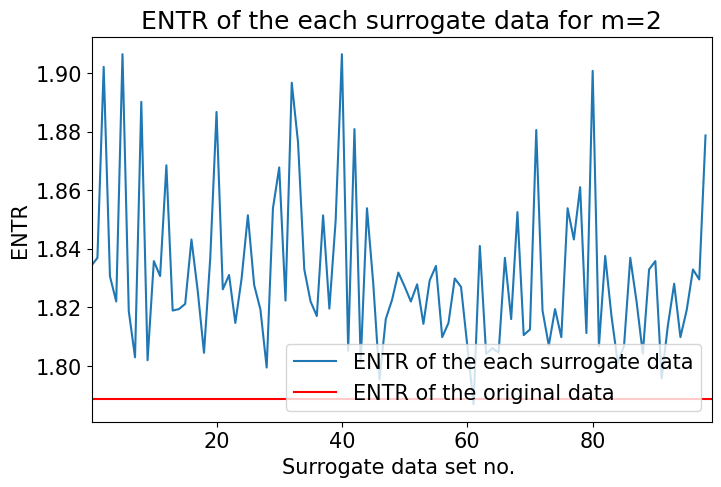

 20%|█████████                                    | 1/5 [00:05<00:20,  5.24s/it]

RQA  stocks Embedding dimensions:2 
 DET of original:0.7542204568005109 
 Recurrence rate: 0.05000231385071035 
Threshold:0.1599999999999987 
 Laminarity:0.8609440074019876 
Shannon Entropy:1.7887444109892805 
Rank-order p-value (det):1.0 
Rank-order p-value (lam):1.0 
Rank-order p-value (entr):0.99 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.0873456421356951
Pseudo-periodic surrogates generated successfullly


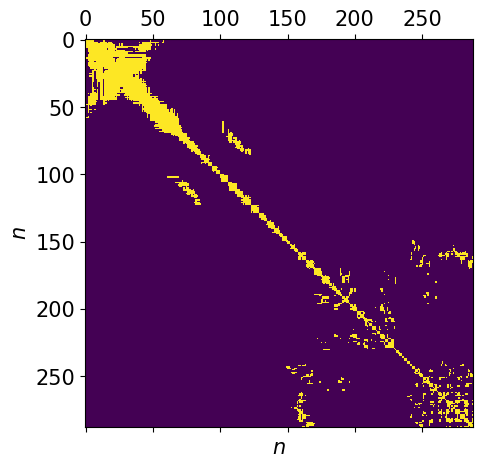

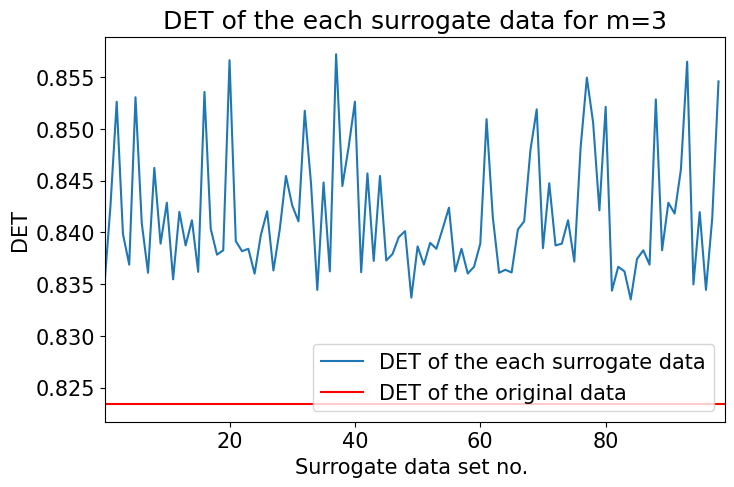

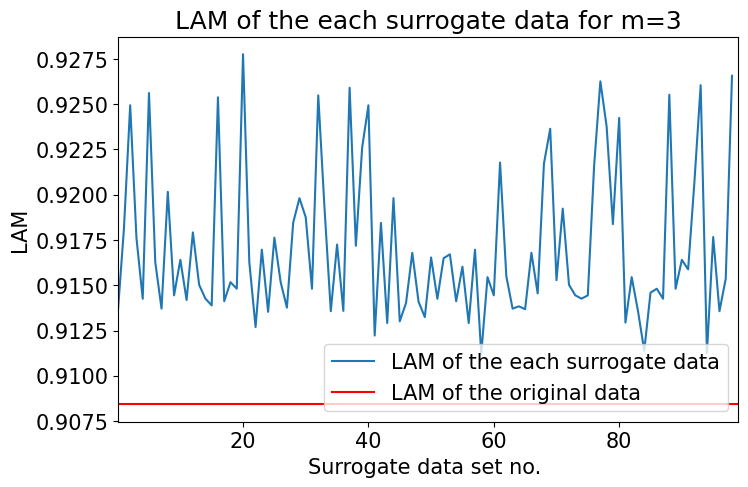

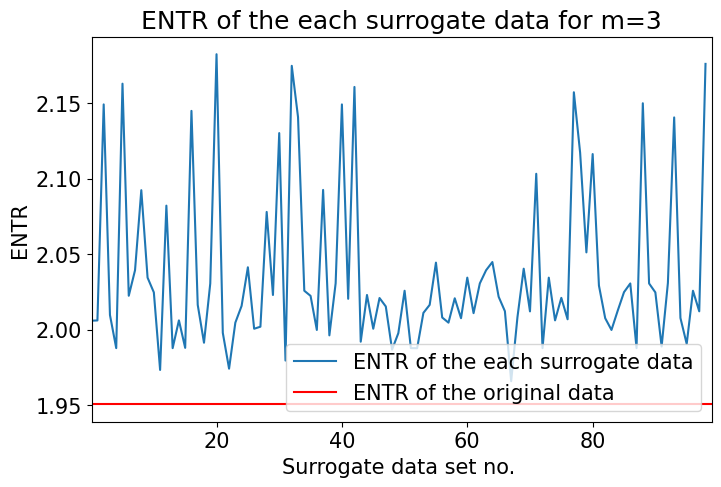

 40%|██████████████████                           | 2/5 [00:11<00:16,  5.63s/it]

RQA  stocks Embedding dimensions:3 
 DET of original:0.8234075608471688 
 Recurrence rate: 0.050033757716049385 
Threshold:0.23889999999999 
 Laminarity:0.9084337349375701 
Shannon Entropy:1.9508420715265373 
Rank-order p-value (det):1.0 
Rank-order p-value (lam):1.0 
Rank-order p-value (entr):1.0 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.12535602890065076
Pseudo-periodic surrogates generated successfullly


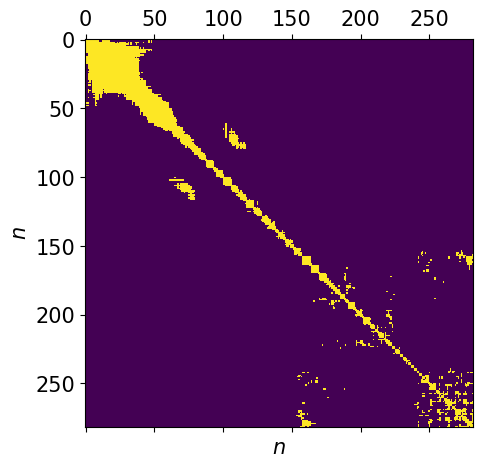

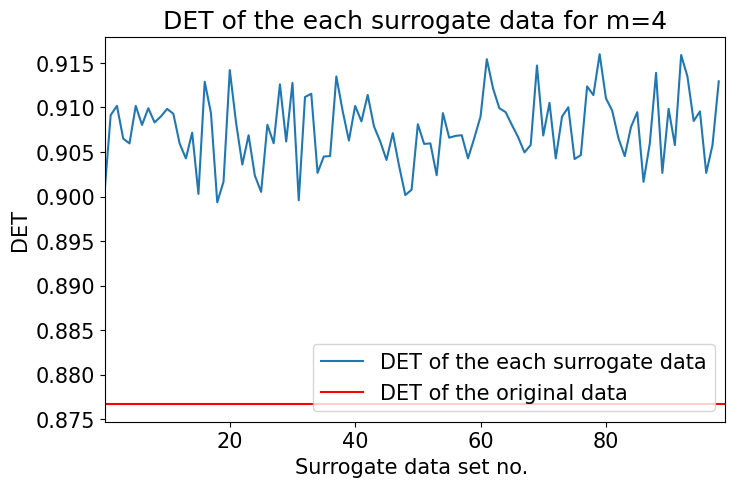

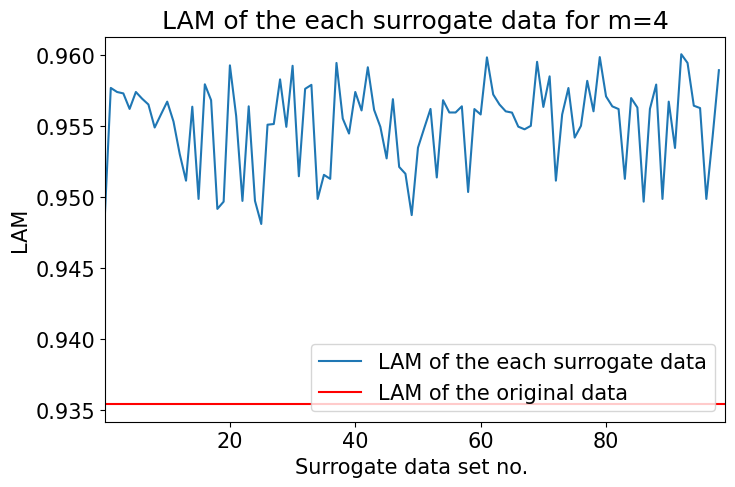

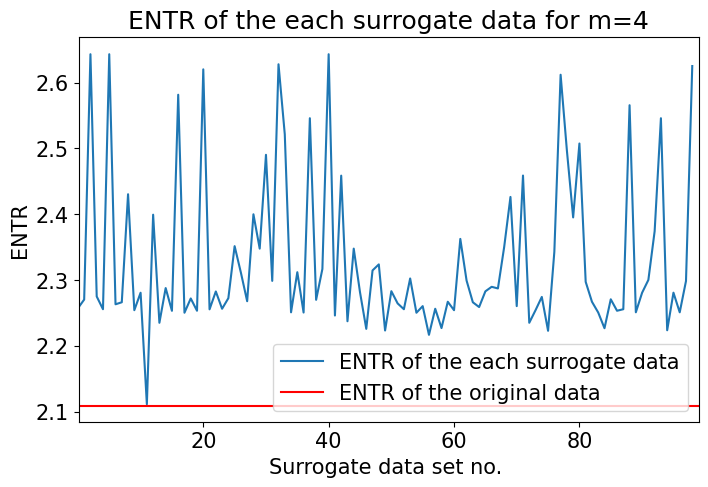

 60%|███████████████████████████                  | 3/5 [00:18<00:12,  6.21s/it]

RQA  stocks Embedding dimensions:4 
 DET of original:0.876690102755877 
 Recurrence rate: 0.050047784316684274 
Threshold:0.3259999999999804 
 Laminarity:0.9354271356760416 
Shannon Entropy:2.1089753584358295 
Rank-order p-value (det):1.0 
Rank-order p-value (lam):1.0 
Rank-order p-value (entr):1.0 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.1548192544025659
Pseudo-periodic surrogates generated successfullly


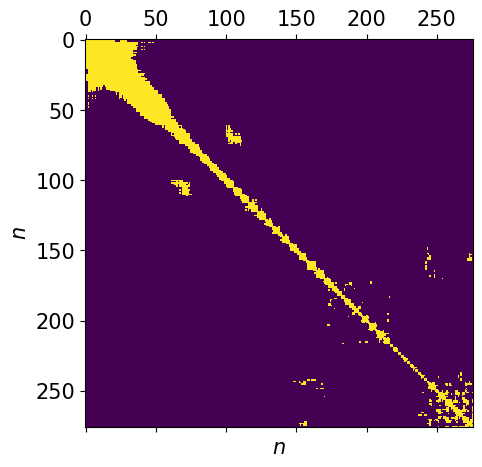

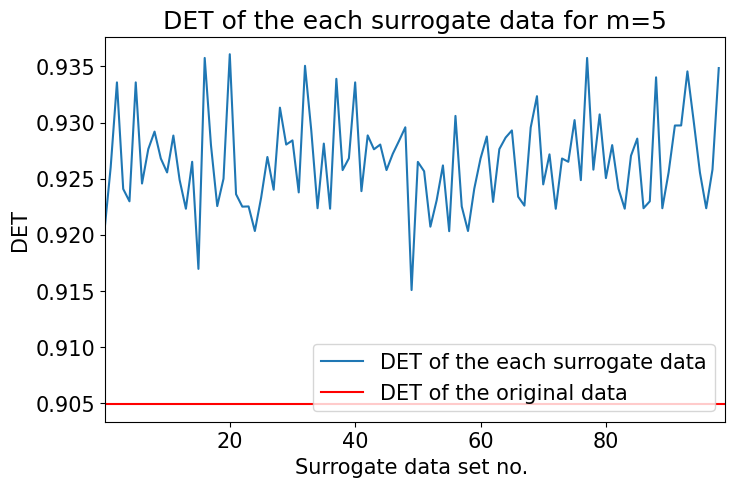

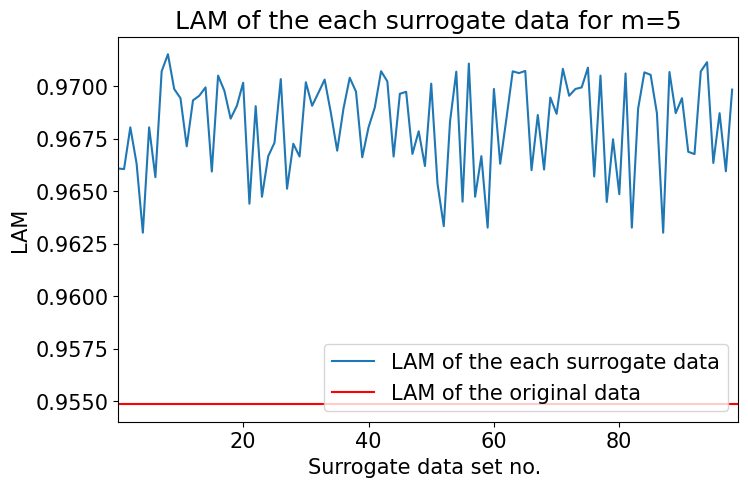

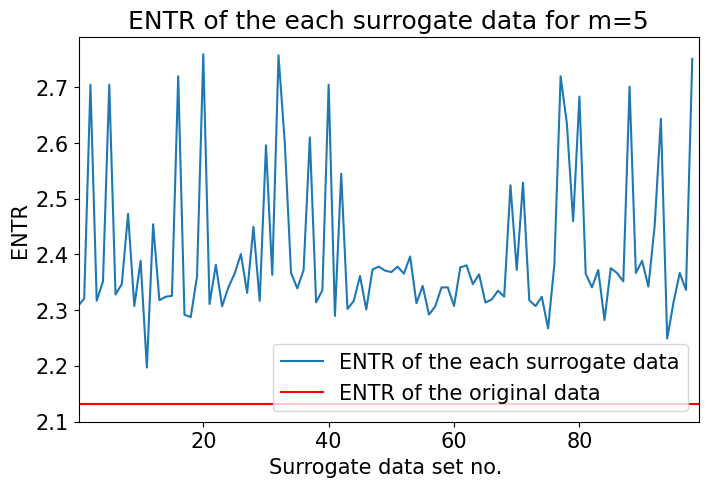

 80%|████████████████████████████████████         | 4/5 [00:25<00:06,  6.88s/it]

RQA  stocks Embedding dimensions:5 
 DET of original:0.9049235993183222 
 Recurrence rate: 0.050015752993068686 
Threshold:0.40469999999997175 
 Laminarity:0.9548556430421132 
Shannon Entropy:2.1310423583923637 
Rank-order p-value (det):1.0 
Rank-order p-value (lam):1.0 
Rank-order p-value (entr):1.0 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 

Mean Nearest Neighbor Distance: 0.17740384209547802
Pseudo-periodic surrogates generated successfullly


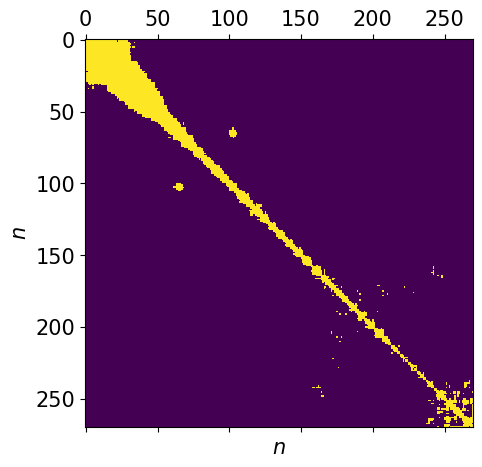

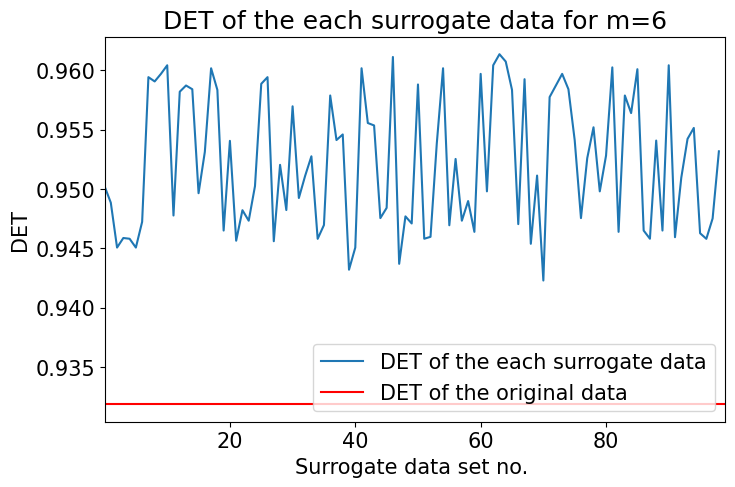

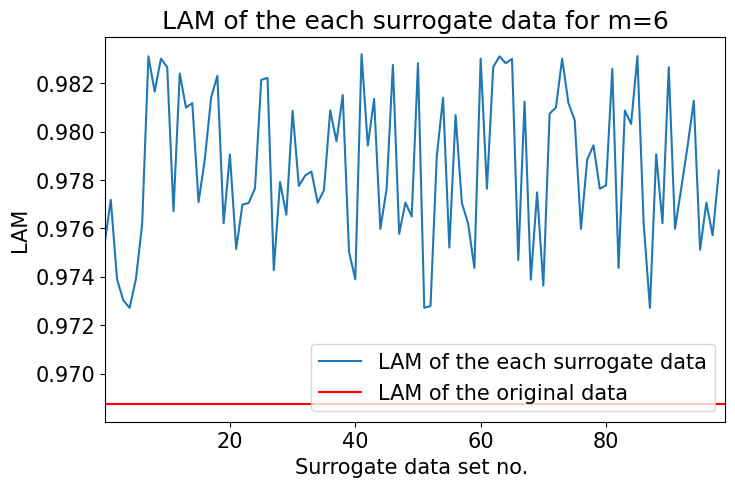

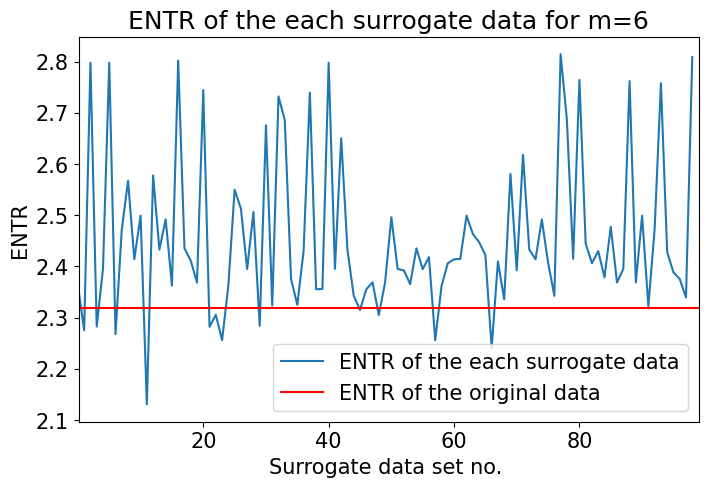

100%|█████████████████████████████████████████████| 5/5 [00:34<00:00,  6.84s/it]

RQA  stocks Embedding dimensions:6 
 DET of original:0.9318720379119317 
 Recurrence rate: 0.05001371742112483 
Threshold:0.48369999999996305 
 Laminarity:0.9687328579238379 
Shannon Entropy:2.318085964176623 
Rank-order p-value (det):1.0 
Rank-order p-value (lam):1.0 
Rank-order p-value (entr):0.88 
Reject null (det) hypothesis:False
 Reject null (lam) hypothesis:False
Reject null (entr) hypothesis:False
 
 



In [11]:
t_min=6
k="stocks"
det_j=[]
embed=[]
det_surro_ff=[]
kkk=[]
lam_j=[]
ent_j=[]
lam_surro = []
ent_surro=[]
s = lcurve(k)
with open("test_output/stocks_PP", "w") as f:
    for dim in tqdm(range(2, 7, 1)):
        tt1=0.001
        dimension=dim
        RR_orig = 0
        while RR_orig < 0.05:
            tt1 = tt1 + 0.0001
            det, RR_orig, lam_orig, entr_orig, matrix= RP_RN(s, dim, tt1)
        orig_rp=RecurrencePlot(s, dim=dimension , tau=t_min, metric = "euclidean", threshold=tt1, normalize=True, silence_level = 3)
        det_j.append(det)
        embed.append(dim)
        lam_j.append(lam_orig)
        ent_j.append(entr_orig)
        pylab.matshow(matrix)
        pylab.xlabel("$n$")
        pylab.ylabel("$n$")
        pylab.savefig('test_output/PP/PP_RP_{}.pdf'.format(dim), format="pdf", dpi=300)
        dist_matrix = orig_rp.euclidean_distance_matrix()
        np.fill_diagonal(dist_matrix, np.inf)
        nearest_neighbor_distances = np.min(dist_matrix, axis=1)
        mean_nn_distance = np.mean(nearest_neighbor_distances)
        print(f"Mean Nearest Neighbor Distance: {mean_nn_distance}")
        noise_rad = 0.7*mean_nn_distance
        subprocess.run(["julia", "PP.jl", str(noise_rad), str(dim)], text=True, check=True)
        det_ff, lam_ff, entr_ff = sur_test_PP(s, dim, tt1)
        fig2, axs = plt.subplots(1)
        axs.plot(det_ff, label = 'DET of the each surrogate data')
        axs.set_title('DET of the each surrogate data for m={}'.format(dimension))
        axs.axhline(y = det, color = 'r', linestyle = '-', label = 'DET of the original data' )
        axs.legend(loc='lower right')
        axs.set_xlabel("Surrogate data set no. ")
        axs.set_xlim(0.1, 99)
        axs.set_ylabel("DET")
        fig2.savefig('test_output/PP/PP_surro_{}.pdf'.format(dim), format="pdf", dpi=300)        
        plt.show()
        plt.close()
        fig, ax = plt.subplots(1)
        ax.plot(lam_ff, label = 'LAM of the each surrogate data')
        ax.set_title('LAM of the each surrogate data for m={}'.format(dimension))
        ax.axhline(y = lam_orig, color = 'r', linestyle = '-', label = 'LAM of the original data' )
        ax.legend(loc='lower right')
        ax.set_xlabel("Surrogate data set no. ")
        ax.set_xlim(0.1, 99)
        ax.set_ylabel("LAM")
        fig.savefig('test_output/PP/PP_surro_{}_LAM.pdf'.format(dim), format="pdf", dpi=300)  
        plt.show()
        plt.close()
        fi, axx1 = plt.subplots(1)
        axx1.plot(entr_ff, label = 'ENTR of the each surrogate data')
        axx1.set_title('ENTR of the each surrogate data for m={}'.format(dimension))
        axx1.axhline(y = entr_orig, color = 'r', linestyle = '-', label = 'ENTR of the original data' )
        axx1.legend(loc='lower right')
        axx1.set_xlabel("Surrogate data set no. ")
        axx1.set_xlim(0.1, 99)
        axx1.set_ylabel("ENTR")
        fi.savefig('test_output/PP/PP_surro_{}_ENTR.pdf'.format(dim), format="pdf", dpi=300)  
        plt.show()
        plt.close()
        r = np.sum(det_ff >= det)
        r1 = np.sum(lam_ff >= lam_orig)
        r2 = np.sum(entr_ff >= entr_orig)
        p_rank = (r + 1) / (99 + 1)
        p_rank_lam =(r1 + 1) / (99 + 1)
        p_rank_entr = (r2 + 1) / (99 + 1)
        alpha = 0.05
        reject_null1 = p_rank < alpha
        reject_null2 = p_rank_lam < alpha
        reject_null3 = p_rank_entr < alpha
        f.write("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        print("RQA  {} Embedding dimensions:{} \n" 
            " DET of original:{} \n"
            " Recurrence rate: {} \n" 
            "Threshold:{} \n "
            "Laminarity:{} \n" 
            "Shannon Entropy:{} \n" 
            "Rank-order p-value (det):{} \n"
            "Rank-order p-value (lam):{} \n"
            "Rank-order p-value (entr):{} \n" 
            "Reject null (det) hypothesis:{}\n Reject null (lam) hypothesis:{}\n"
            "Reject null (entr) hypothesis:{}\n \n \n".format(k, dim, det, RR_orig, tt1, lam_orig, entr_orig, 
                                                              p_rank, p_rank_lam, p_rank_entr, reject_null1, reject_null2, 
                                                              reject_null3))
        det_surro_ff.append(det_ff)
        kkk.append(np.full(99, dimension))
        lam_surro.append(lam_ff)
        ent_surro.append(entr_ff)

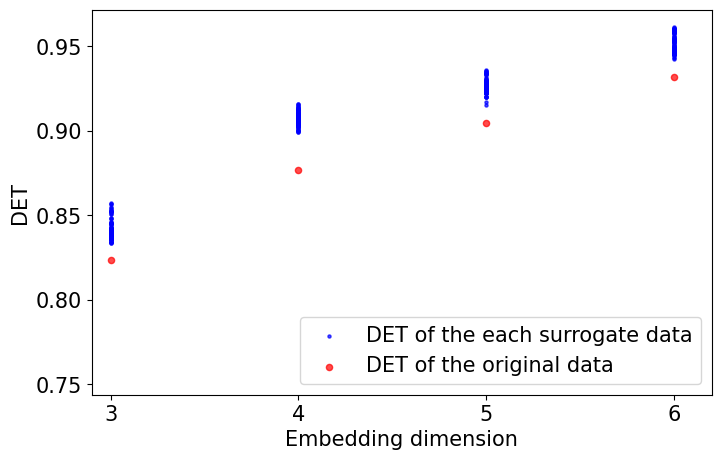

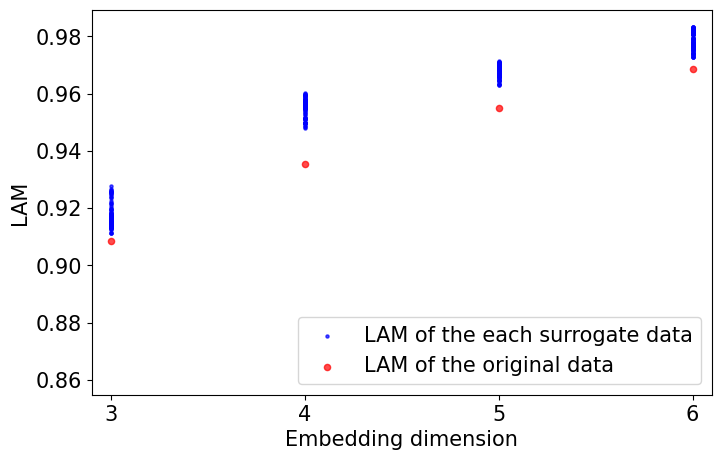

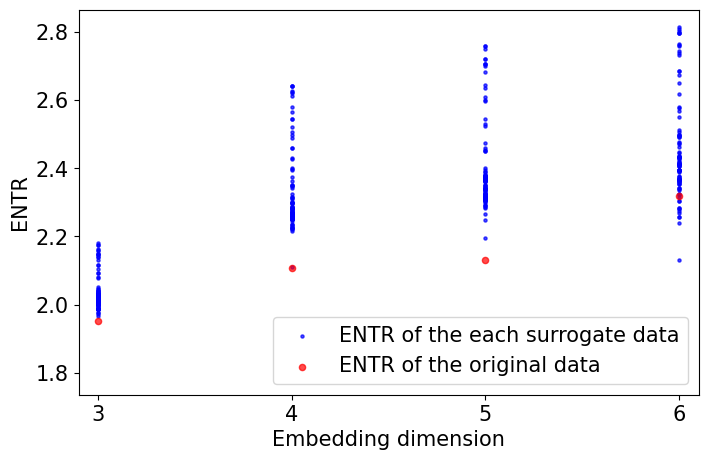

In [12]:
fig3, ax3 = plt.subplots(1)
ax3.scatter(np.concatenate(kkk), np.concatenate(det_surro_ff), color='blue', alpha=0.7, s=5, label = "DET of the each surrogate data")
ax3.scatter(embed, det_j, color='red', alpha=0.7, s=20, label='DET of the original data')
ax3.set_xlim(2.9, 6.2)
ax3.set_xticks(np.arange(3, 7, 1))
ax3.set_xlabel("Embedding dimension")
ax3.set_ylabel("DET")
ax3.legend(loc='lower right')
fig3.savefig('test_output/PP/PP_surro_m.pdf', format="pdf", dpi=300)
plt.show()
plt.close()
fig4, ax4 = plt.subplots(1)
ax4.scatter(np.concatenate(kkk), np.concatenate(lam_surro), color='blue', alpha=0.7, s=5, label = "LAM of the each surrogate data")
ax4.scatter(embed, lam_j, color='red', alpha=0.7, s=20, label='LAM of the original data')
ax4.set_xlim(2.9, 6.1)
ax4.set_xlabel("Embedding dimension")
ax4.set_ylabel("LAM")
ax4.legend(loc='lower right')
ax4.set_xticks(np.arange(3, 7, 1))
fig4.savefig('test_output/PP/PP_surro_lam_m.pdf', format="pdf", dpi=300)
plt.show()
plt.close()
fig5, ax5 = plt.subplots(1)
ax5.scatter(np.concatenate(kkk), np.concatenate(ent_surro), color='blue', alpha=0.7, s=5, label = "ENTR of the each surrogate data")
ax5.scatter(embed, ent_j, color='red', alpha=0.7, s=20, label='ENTR of the original data')
ax5.set_xlim(2.9, 6.1)
ax5.set_xlabel("Embedding dimension")
ax5.set_ylabel("ENTR")
ax5.legend(loc='lower right')
ax5.set_xticks(np.arange(3, 7, 1))
fig5.savefig('test_output/PP/PP_surro_entr_m.pdf', format="pdf", dpi=300)
plt.show()
plt.close()

# Delay Embedding

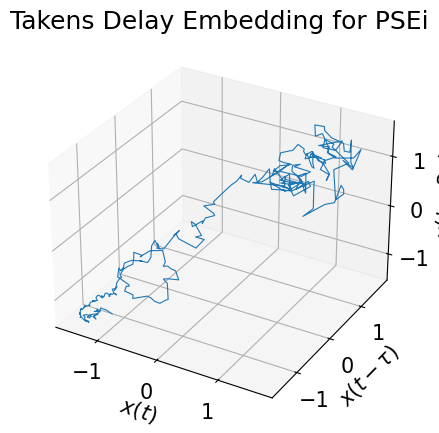

In [13]:
from mpl_toolkits.mplot3d import Axes3D  
rp = RecurrencePlot(data, dim=4, tau=6, metric="euclidean", normalize=True,   silence_level=3,threshold = 0.326)
X = rp.embedding


fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.plot(X[:, 0], X[:, 1], X[:, 2], lw=0.8)
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(r"$x(t-\tau)$")
ax.set_zlabel(r"$x(t-2\tau)$")
ax.set_title("Takens Delay Embedding for PSEi")
fig.savefig("delay_embed.pdf", format="pdf", dpi=300)
plt.show()
plt.close()

NameError: name 'norm' is not defined

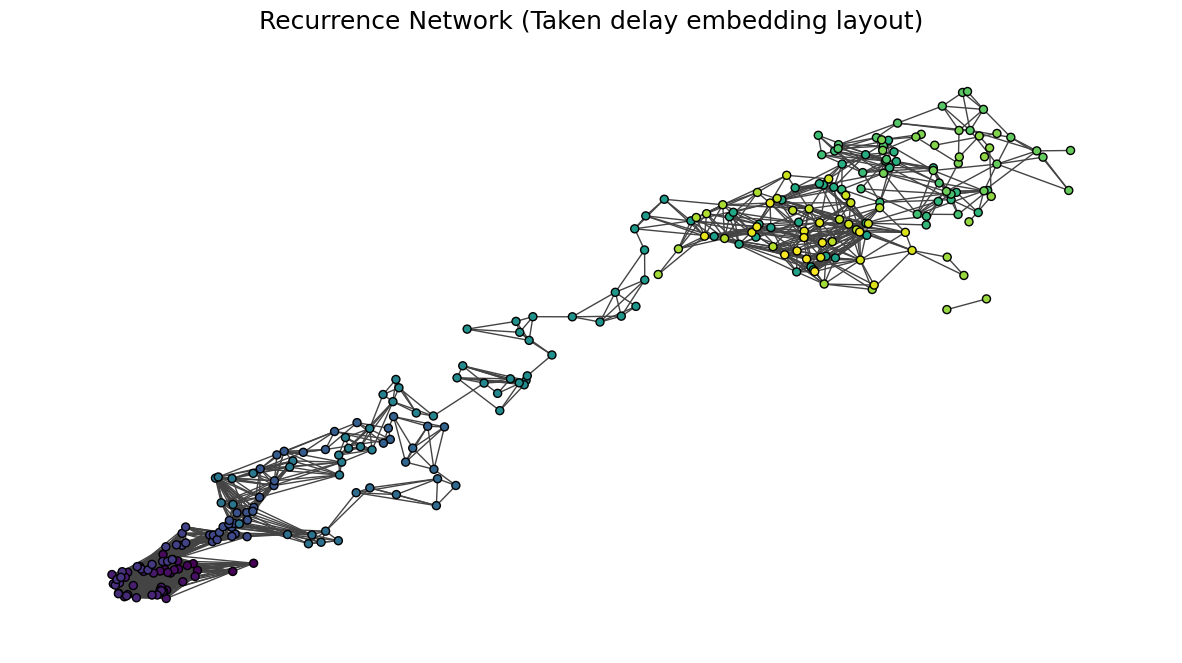

In [14]:
from pyunicorn.timeseries import RecurrenceNetwork
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import calendar


months = []
for year in range(2000, 2025):
    for m in range(1, 13):
        months.append(f"{calendar.month_abbr[m]} {year}")


indices = [0, 50, 100, 150, 200, 250, 299]  #

selected_labels = [months[i] for i in indices]


rn = RecurrenceNetwork(data,dim=4,tau=6,metric="euclidean",threshold=0.326,normalize=True, silence_level=3)
coords = X[:, [0, 1]] 

A = rn.adjacency
g = ig.Graph.Adjacency(A.tolist(), mode="undirected")
g_size = g.vcount()
layout = ig.Layout(coords.tolist())

colors = [plt.cm.viridis(i / g.vcount()) for i in range(g.vcount())]

fig, ax = plt.subplots(figsize=(15, 8))
ig.plot(g,target=ax,layout=layout,vertex_size=8,vertex_color=colors,edge_width=1)

ax.set_title("Recurrence Network (Taken delay embedding layout)")
cmap = plt.cm.viridis


sm = ScalarMappable(norm=norm, cmap=plt.cm.viridis)
sm.set_array([])


cbar = fig.colorbar(sm, ax=ax, orientation='vertical',fraction=0.03, pad=0.05)

tick_positions = np.linspace(1, g_size, len(indices))

cbar.set_ticks(tick_positions)
cbar.set_ticklabels(selected_labels)
cbar.set_label('Month-Year of PSEi data series', fontsize=12)
fig.savefig("network.pdf", format="pdf", dpi=300)


plt.show()
plt.close()